In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
matdir = os.path.join(os.getcwd(), "data", "structural_data", "Sch100")

print(datadir)
print(matdir)

/home/lena/Promotion/neurolib/neurolib/whole-brain
/home/lena/Promotion/neurolib/data/structural_data/Sch100


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import nctpy.utils
import nctpy.metrics

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 0.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 1.0

In [4]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(matdir, f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(matdir, f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

In [6]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data = dict()
data["coordinates"] = coords[0]

data["weights"] = np.zeros((100))
data["control"] = [None] * len(data["weights"])
data["state"] = [None] * len(data["weights"])
data["init_state"] = None
data["energy_input"] = np.zeros((len(data["weights"])))
data["sync_cost"] = np.zeros((len(data["weights"])))

In [27]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, fat=[], filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(32,8), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        if n in fat:
            ax[0].plot(time_array, s[n,0,:], linewidth=4)
        else:
            ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,0,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, wi, mc):
    d["control"][wi] = mc.control.copy()
    d["state"][wi] = mc.get_xs()

def dump_data():
    with open(os.path.join(datadir, 'wb_L1_var_0.pickle'), 'wb') as f:
        pickle.dump(data, f)

controlmat = np.zeros((N,2))
controlmat[:,0] = 1

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  1


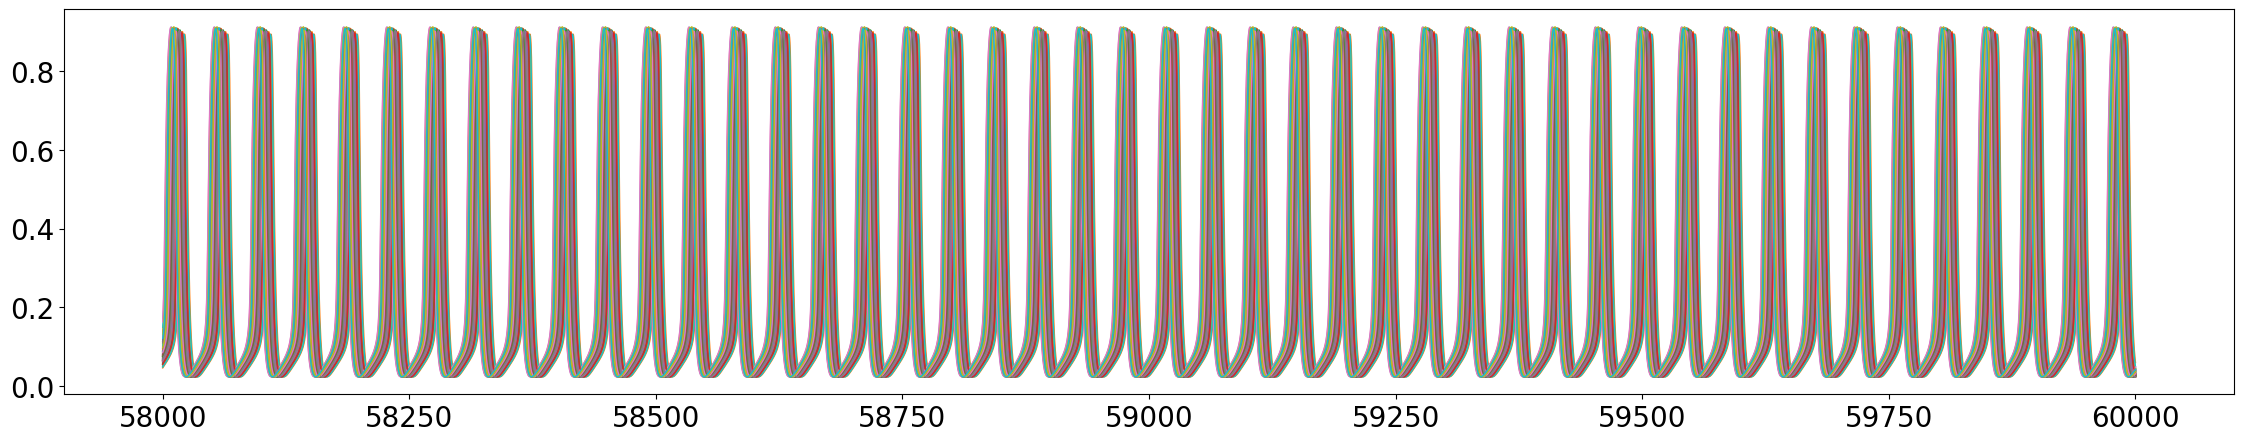

In [23]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):

    if i_s != 0: break

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    model.params.exc_ext_baseline = data["coordinates"][0]
    model.params.exc_inh_baseline = data["coordinates"][1]
    model.run()

    plt.figure(figsize=(28,5))
    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]

    if i_s == 0:
        data["init_state"] = [einit, iinit]
    else:
        data["init_state"] = [einit, iinit]

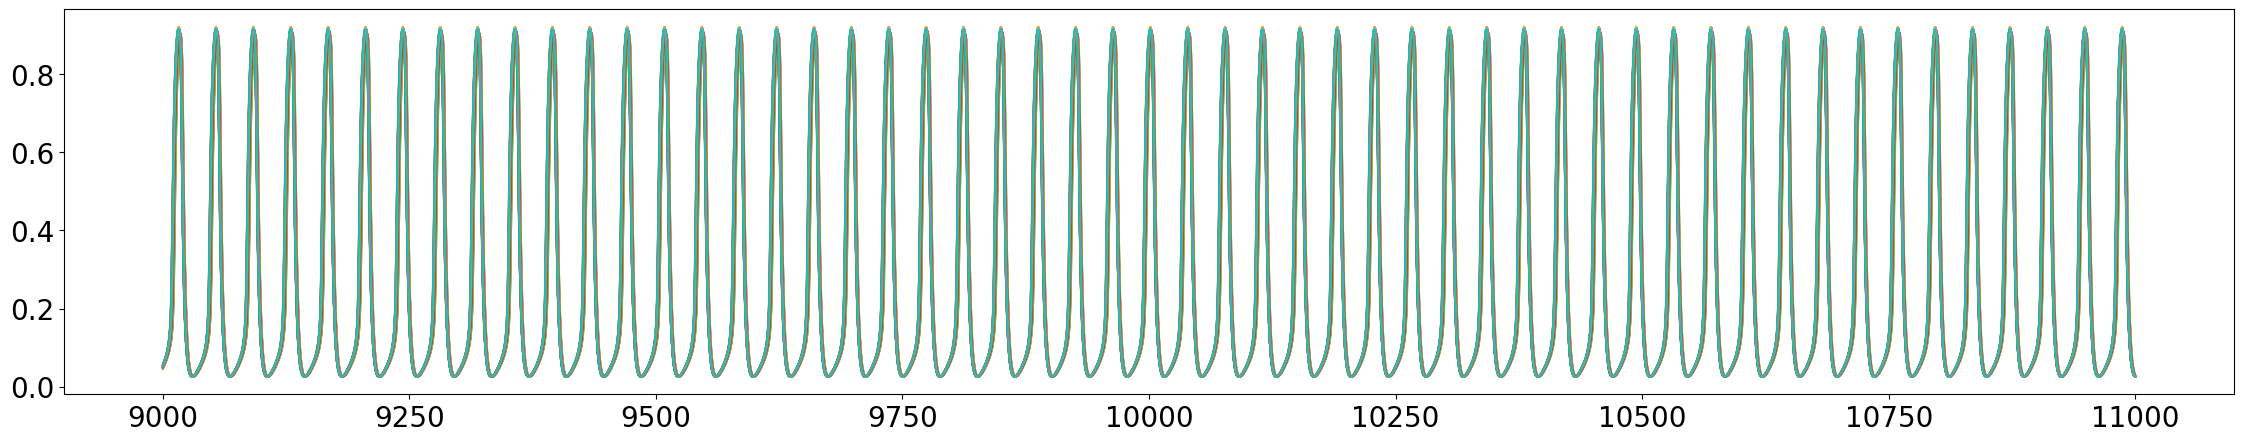

0.002332105821483664
-0.9775374609292389


In [8]:
model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
testd = 11.*1e3   ## needs to stay 11
dt = model.params.dt
model.params.duration = testd
setparams(model)

model.params.exc_ext_baseline = data_2_L1["coordinates"][0]
model.params.exc_inh_baseline = data_2_L1["coordinates"][1]

#model.params.exc_ext = input
model.run()

plt.figure(figsize=(28,5))

for n in range(N):
    plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
plt.show()

nmaxdelay = model.getMaxDelay()
einit = np.zeros((N, nmaxdelay+1))
iinit = np.zeros((N, nmaxdelay+1))

for n in range(N):
    einit[n,:] = model.exc[n,-nmaxdelay-1:]
    iinit[n,:] = model.inh[n,-nmaxdelay-1:]

data_2_L1["init_state"] = [einit, iinit]

var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(var_cost_asyn)

cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(cc_cost)

In [6]:
with open(os.path.join(datadir, 'wb_L1_var_0.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data = data_read

[-150.0, -240.0, -600.0]
[700.0, 800.0, 600.0]
[-300.0, -360.0, -400.0]


In [33]:
print(data["weights"])


[  -10.   -20.   -30.   -40.   -50.   -60.   -70.   -80.   -90.  -100.
  -110.  -120.  -130.  -140.  -150.  -160.  -170.  -180.  -190.  -200.
  -210.  -220.  -230.  -240.  -250.  -260.  -270.  -280.  -290.  -300.
  -310.  -320.  -330.  -340.  -350.  -360.  -370.  -380.  -390.  -400.
  -410.  -420.  -430.  -440.  -450.  -460.  -470.  -480.  -490.  -500.
  -510.  -520.  -530.  -540.  -550.  -560.  -570.  -580.  -590.  -600.
  -610.  -620.  -630.  -640.  -650.  -660.  -670.  -680.  -690.  -700.
  -710.  -720.  -730.  -740.  -750.  -760.  -770.  -780.  -790.  -800.
  -810.  -820.  -830.  -840.  -850.  -860.  -870.  -880.  -890.  -900.
  -910.  -920.  -930.  -940.  -950.  -960.  -970.  -980.  -990. -1000.]


In [32]:
data["weights"][0] = -10.
for n in range(1, N, 1):
    data["weights"][n] = data["weights"][n-1]-10

------------------------------------------------------------ wi =  0
------------------------------------------------------------ wi =  1
------------------------------------------------------------ wi =  2
------------------------------------------------------------ wi =  3
------------------------------------------------------------ wi =  4
------------------------------------------------------------ wi =  5
------------------------------------------------------------ wi =  6
------------------------------------------------------------ wi =  7
------------------------------------------------------------ wi =  8
------------------------------------------------------------ wi =  9
------------------------------------------------------------ wi =  10
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -3.533732222413866
Final cost : -3.533732222413866
Compute control for a deterministic system
Cost in iteration 0: -3.53373222241

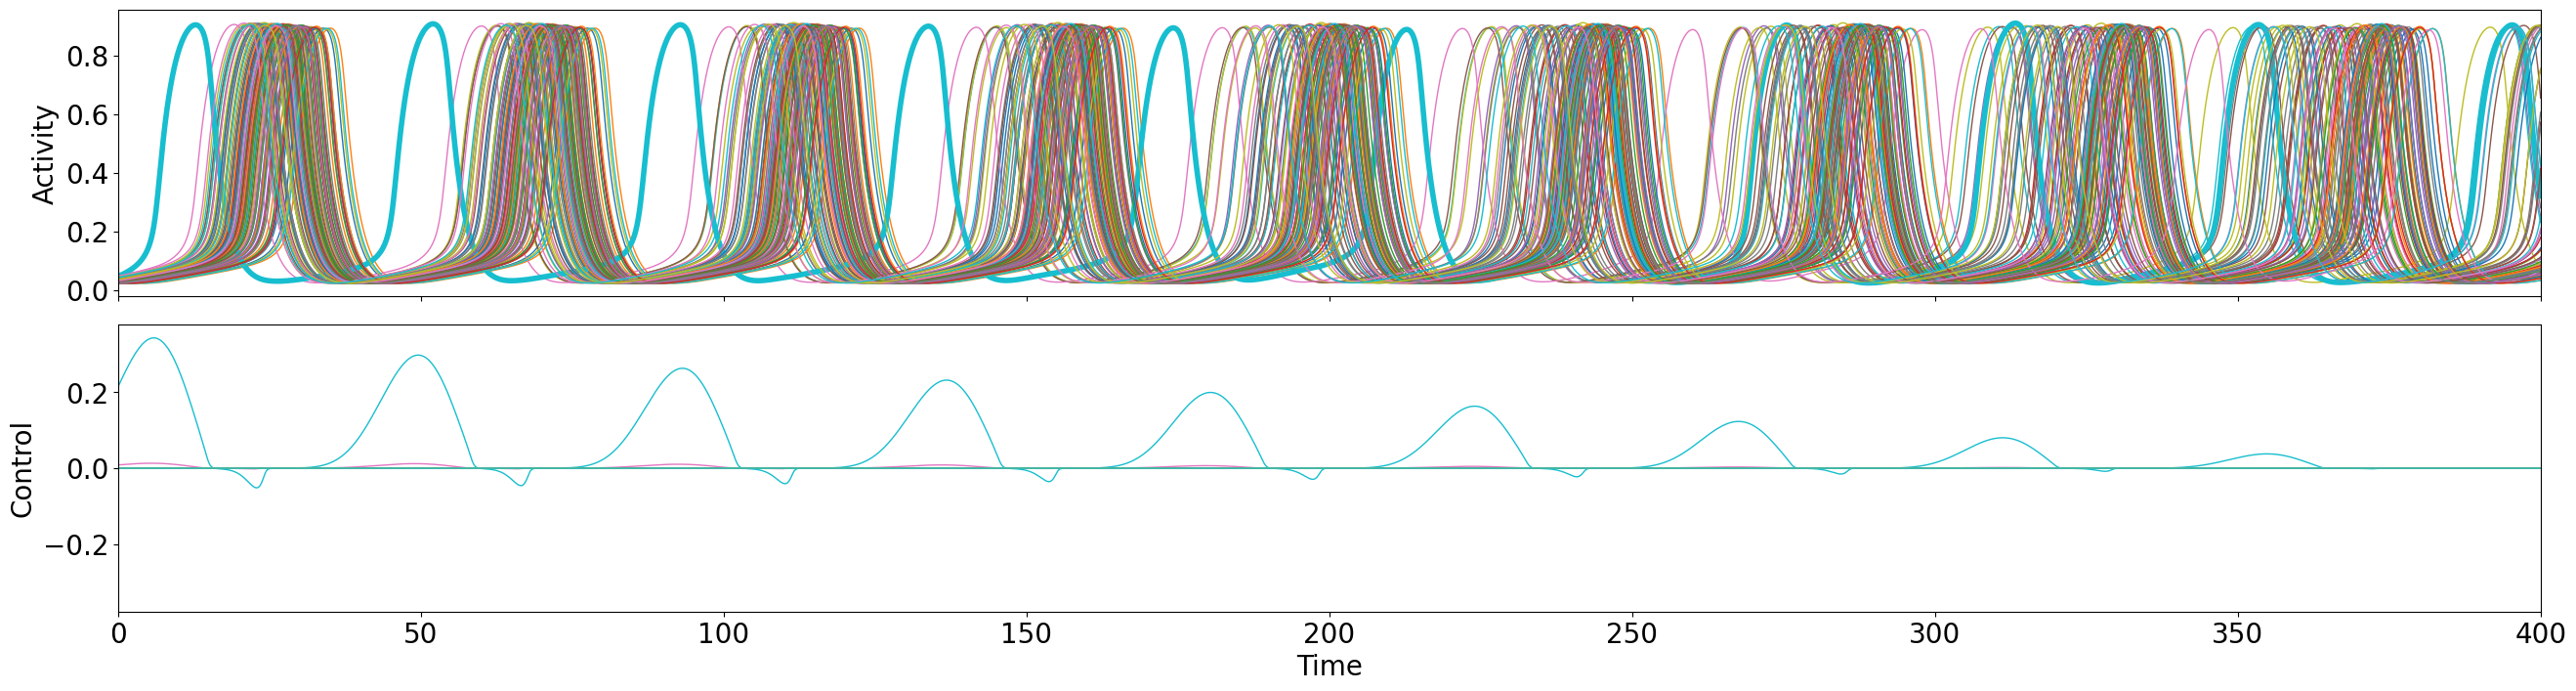

------------------------------------------------------------ wi =  11
------------------------------------------------------------ wi =  12
------------------------------------------------------------ wi =  13
------------------------------------------------------------ wi =  14
------------------------------------------------------------ wi =  15
------------------------------------------------------------ wi =  16
------------------------------------------------------------ wi =  17
------------------------------------------------------------ wi =  18
------------------------------------------------------------ wi =  19
------------------------------------------------------------ wi =  20
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -6.746216060971929
Final cost : -6.746216060971929
Compute control for a deterministic system
Cost in iteration 0: -6.746216060971929
Cost in iteration 1: -6.916683966569649
Cost in iterati

In [ ]:
it = 2

for wi in range(100):
    print("------------------------------------------------------------ wi = ", wi)

    if wi not in [10, 20, 30]: continue

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = data["init_state"][0]
    model.params.inh_init = data["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  data["coordinates"][0]
    model.params["inh_ext_baseline"] =  data["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_var"] = data["weights"][wi]

    model_controlled.maximum_control_strength = max_cntrl

    if type(data["control"][wi]) != type(None):
        model_controlled.control = data["control"][wi].copy()
        model_controlled.update_control()

    # find initial signal
    model_controlled.channelwise_optimization = True
    model_controlled.step = 1e8
    model_controlled.optimize(0)

    get_results(data, wi, model_controlled)
    dump_data()

    for j in range(1):
        model_controlled.grad_method = 0

        for k in [-4, 4]:
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            get_results(data, wi, model_controlled)
            dump_data()

        model_controlled.grad_method = 1

        for k in range(-2, 4, 2):
            break
            model_controlled.zero_step_encountered = False
            model_controlled.step = 10.**(k)
            model_controlled.optimize(it)

            get_results(data, wi, model_controlled)
            dump_data()
    
    maxnodeind = np.argmax(np.sum(np.sum(data["control"][wi]**2, axis=2), axis=1))
    print("max node ind = ", maxnodeind)
    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, fat=[maxnodeind], filename=None, title=None)